# Projekt AI vs człowiek

Projekt polega na zbudowaniu modelu, który najlepiej odróżni tekst wygenerowany przez AI od tekstu napisanego przez człowieka. W tym celu wykorzystałem dostępne narzędzia, żeby wyodrębnić jak najwięcej informacji z tekstu, które następnie zasiliły modele uczenia maszynowego. Udało się uzyskać accuracy = 96.7%

In [2]:
import pandas as pd

In [3]:
# dane: https://www.kaggle.com/datasets/shanegerami/ai-vs-human-text?resource=download

data = pd.read_csv("C:/Users/Mariusz/OneDrive/Pulpit/StudiaPodyplomowe/Projekty_do CV/AI_human/dane/AI_human.csv")

In [4]:
data.head()

,text,generated
0,Cars. Cars have been around since they became ...,0.0
1,Transportation is a large necessity in most co...,0.0
2,"""America's love affair with it's vehicles seem...",0.0
3,How often do you ride in a car? Do you drive a...,0.0
4,Cars are a wonderful thing. They are perhaps o...,0.0


In [5]:
data["length"] = data["text"].apply(len)

In [6]:
data.head()

,text,generated,length
0,Cars. Cars have been around since they became ...,0.0,3289
1,Transportation is a large necessity in most co...,0.0,2738
2,"""America's love affair with it's vehicles seem...",0.0,4428
3,How often do you ride in a car? Do you drive a...,0.0,4013
4,Cars are a wonderful thing. They are perhaps o...,0.0,4698


In [7]:
data["word_count"] = data["text"].apply(lambda x: len(str(x).split()))

In [8]:
data.head()

,text,generated,length,word_count
0,Cars. Cars have been around since they became ...,0.0,3289,584
1,Transportation is a large necessity in most co...,0.0,2738,462
2,"""America's love affair with it's vehicles seem...",0.0,4428,744
3,How often do you ride in a car? Do you drive a...,0.0,4013,686
4,Cars are a wonderful thing. They are perhaps o...,0.0,4698,871


In [9]:
print(data.loc[13, "text"])

dear senator, I have come to a conclusion on how I think the president and his candidates should be voted for. In one hand we've got the Electoral College, and the election by popular vote. These two thing have been around for hundreds of years but you've got to know if you prefer one or the other. So which one works better? Why do you prefer this one over the other?

The Electoral College, electors meeting and voting for our president and vice president. This electoral college consist of 538 electors that vote to for our president. I myself dont think this is a very sensible thing. Because when you think you're voting for the president you are actually voting for a state of electors who will in turn vote for the president not you. Why should there be a select few people out of the billions of people who live in america to vote for the president while we just sit and wait for the results. To only have their opinions voiced. Does'nt seem like a very fair way to elect someone who will be

In [10]:
print(data.loc[129, "text"])

The Electoral college is a process where electors vote for President and Vice President, and count the number of electoral votes by Congress. Many people are debating whether or not keep the Electoral collegee or change it to a election by popular vote for the president of the United States. Although the Electoral collegee has been taking place for many years now, it can be a disaster factor. I believe that the Electoral collegee should be abolished and changed to a election by popular vote for the president of the United States because it will make the election fair, the chance of there being a tie is much less, and it will be rather rational as oposed to the Electoral collegee.

The Electoral collegee is not fair and it is irrational. Voters don't vote directly to the president they want. According to Source 1: "What is the Electoral collegee?" voters actually voting for their candidate's electors. Majority of the states have a "winner take all" system in which electors are awarded t

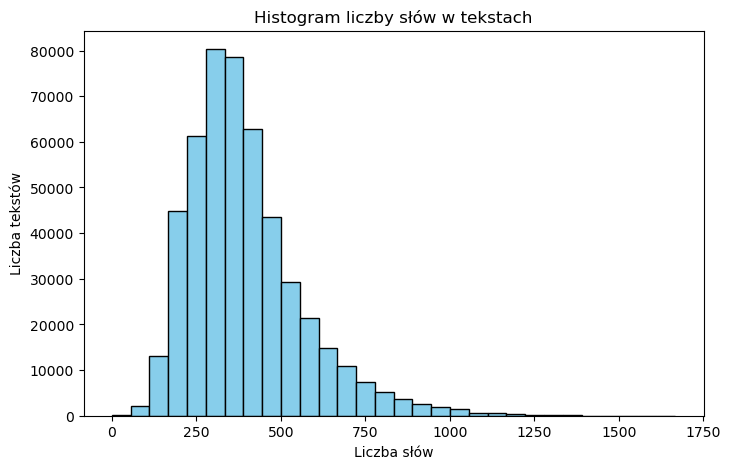

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(data["word_count"], bins=30, color='skyblue', edgecolor='black')
plt.title("Histogram liczby słów w tekstach")
plt.xlabel("Liczba słów")
plt.ylabel("Liczba tekstów")
plt.show()

Projekt głównie służy prezentacji umiejętności a danych jest bardzo dużo (500k) więc w celu zoptymalizowania mocy obliczeniowej oraz możliwości łatwego zastosowania modeli osadzeń chcę wyrzucić teksty powyżej 320 słów

In [13]:
data = data[data["word_count"] <= 320].reset_index(drop=True)

In [14]:
data["word_count"].describe()

count    181974.000000
mean        244.412955
std          52.629737
min           0.000000
25%         207.000000
50%         253.000000
75%         288.000000
max         320.000000
Name: word_count, dtype: float64

Pozostało 189 tys. tekstów

In [16]:
data["generated"].value_counts()

generated
0.0    103711
1.0     78263
Name: count, dtype: int64

AI = 1
Człowiek = 0

Bierzemy 10000 tekstów żeby modele językowe zadziałały - ze względu na ograniczenia sprzętu

In [19]:
# liczba próbek z każdej klasy
n_samples = 5000

# losowe próbkowanie po klasach
sample_ai = data[data['generated'] == 1.0].sample(n_samples, random_state=42)
sample_human = data[data['generated'] == 0.0].sample(n_samples, random_state=42)

# połączenie w jedną zbalansowaną próbkę
data = pd.concat([sample_ai, sample_human]).reset_index(drop=True)

# potasowanie, żeby AI i ludzie się wymieszali
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

# sprawdź rozkład
print(data['generated'].value_counts())


generated
0.0    5000
1.0    5000
Name: count, dtype: int64


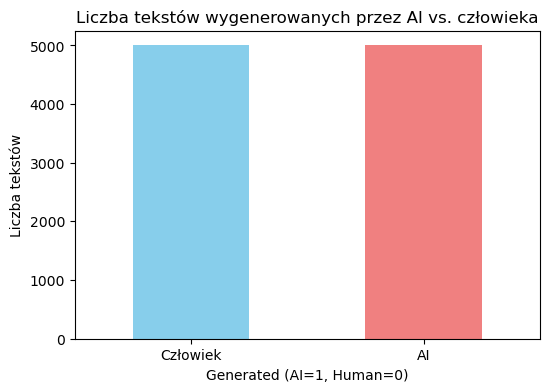

In [20]:
import matplotlib.pyplot as plt

# Dane do wykresu
counts = data["generated"].value_counts()

# Wykres słupkowy
plt.figure(figsize=(6, 4))
counts.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Liczba tekstów wygenerowanych przez AI vs. człowieka')
plt.xlabel('Generated (AI=1, Human=0)')
plt.ylabel('Liczba tekstów')
plt.xticks(ticks=[0, 1], labels=['Człowiek', 'AI'], rotation=0)
plt.show()

In [21]:
import re

In [22]:
def clean_text(t):
    t = str(t)
    t = re.sub(r"http\S+", "", t)
    t = re.sub(r"[^A-Za-z0-9\s.,!?']", " ", t)
    t = re.sub(r"\s+", " ", t).strip() 
    return t

data["text"] = data["text"].apply(clean_text)

In [23]:
data = data.drop_duplicates(subset="text").reset_index(drop=True)

In [24]:
data.describe()

,generated,length,word_count
count,9962.000000,9962.000000,9962.000000
mean,0.500100,1417.835575,244.094158
std,0.500025,355.348719,53.928730
min,0.000000,99.000000,16.000000
25%,0.000000,1162.000000,207.000000
50%,1.000000,1438.500000,253.000000
75%,1.000000,1685.750000,289.000000
max,1.000000,4223.000000,320.000000


In [25]:
data = data[data["word_count"] > 5]

In [26]:
data.describe()

,generated,length,word_count
count,9962.000000,9962.000000,9962.000000
mean,0.500100,1417.835575,244.094158
std,0.500025,355.348719,53.928730
min,0.000000,99.000000,16.000000
25%,0.000000,1162.000000,207.000000
50%,1.000000,1438.500000,253.000000
75%,1.000000,1685.750000,289.000000
max,1.000000,4223.000000,320.000000


In [27]:
data.head()

,text,generated,length,word_count
0,This is a story about a young man who is 18 ye...,0.0,1389,271
1,There is no question that the number of cars i...,1.0,1424,241
2,Drivers Should Not Use Cell Phones in Any Capa...,1.0,1798,282
3,"Hey, you all! So, like, determination is totes...",1.0,1613,292
4,Studying Venus is Worth the Risk The author ma...,1.0,1661,247


In [28]:
import numpy as np

In [29]:
data["avg_word_len"] = data["text"].apply(
    lambda x: np.mean([len(re.sub(r"[^A-Za-z0-9]", "", w))
                       for w in str(x).split() if w])
)

In [30]:
data.head()

,text,generated,length,word_count,avg_word_len
0,This is a story about a young man who is 18 ye...,0.0,1389,271,3.926471
1,There is no question that the number of cars i...,1.0,1424,241,4.784232
2,Drivers Should Not Use Cell Phones in Any Capa...,1.0,1798,282,5.007067
3,"Hey, you all! So, like, determination is totes...",1.0,1613,292,4.160410
4,Studying Venus is Worth the Risk The author ma...,1.0,1661,247,5.595142


In [31]:
data.head()

,text,generated,length,word_count,avg_word_len
0,This is a story about a young man who is 18 ye...,0.0,1389,271,3.926471
1,There is no question that the number of cars i...,1.0,1424,241,4.784232
2,Drivers Should Not Use Cell Phones in Any Capa...,1.0,1798,282,5.007067
3,"Hey, you all! So, like, determination is totes...",1.0,1613,292,4.160410
4,Studying Venus is Worth the Risk The author ma...,1.0,1661,247,5.595142


In [32]:
data.describe()

,generated,length,word_count,avg_word_len
count,9962.000000,9962.000000,9962.000000,9962.000000
mean,0.500100,1417.835575,244.094158,4.642975
std,0.500025,355.348719,53.928730,0.530122
min,0.000000,99.000000,16.000000,3.274390
25%,0.000000,1162.000000,207.000000,4.261604
50%,1.000000,1438.500000,253.000000,4.553409
75%,1.000000,1685.750000,289.000000,4.949638
max,1.000000,4223.000000,320.000000,9.049020


In [33]:
import nltk
nltk.download('punkt')
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Mariusz\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Mariusz\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Mariusz\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [34]:
from nltk.stem import WordNetLemmatizer
import re
from nltk.tokenize import word_tokenize

In [35]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Mariusz\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Mariusz\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [36]:
lemmatizer = WordNetLemmatizer()

In [37]:
def text_features(text):
    # Usuwamy linki, liczby i inne znaki
    text = re.sub(r'[^a-zA-Z\s.,!?;:]', '', text.lower())
    tokens = word_tokenize(text)

    # Lematyzacja
    lemmas = [lemmatizer.lemmatize(w) for w in tokens if w.isalpha()]

    if len(lemmas) == 0:
        return pd.Series({
            'unique_word_ratio': 0,
            'stopword_ratio': 0,
            'punctuation_ratio': 0
        })

    unique_words = len(set(lemmas))
    stopword_ratio = sum(1 for w in lemmas if w in stop_words) / len(lemmas)
    punctuation_ratio = sum(1 for c in text if c in ".,!?;:") / len(text)

    return pd.Series({
        'unique_word_ratio': unique_words / len(lemmas),
        'stopword_ratio': stopword_ratio,
        'punctuation_ratio': punctuation_ratio
    })

In [38]:
extra_features = data['text'].apply(text_features)

data = pd.concat([data, extra_features], axis=1)

data.head()

,text,generated,length,word_count,avg_word_len,unique_word_ratio,stopword_ratio,punctuation_ratio
0,This is a story about a young man who is 18 ye...,0.0,1389,271,3.926471,0.424354,0.479705,0.024799
1,There is no question that the number of cars i...,1.0,1424,241,4.784232,0.502075,0.427386,0.017630
2,Drivers Should Not Use Cell Phones in Any Capa...,1.0,1798,282,5.007067,0.531915,0.375887,0.015643
3,"Hey, you all! So, like, determination is totes...",1.0,1613,292,4.160410,0.506849,0.462329,0.043065
4,Studying Venus is Worth the Risk The author ma...,1.0,1661,247,5.595142,0.581301,0.353659,0.015748


In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9962 entries, 0 to 9961
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   text               9962 non-null   object 
 1   generated          9962 non-null   float64
 2   length             9962 non-null   int64  
 3   word_count         9962 non-null   int64  
 4   avg_word_len       9962 non-null   float64
 5   unique_word_ratio  9962 non-null   float64
 6   stopword_ratio     9962 non-null   float64
 7   punctuation_ratio  9962 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 622.8+ KB


In [40]:
data.describe()

,generated,length,word_count,avg_word_len,unique_word_ratio,stopword_ratio,punctuation_ratio
count,9962.000000,9962.000000,9962.000000,9962.000000,9962.000000,9962.000000,9962.000000
mean,0.500100,1417.835575,244.094158,4.642975,0.498187,0.461012,0.017526
std,0.500025,355.348719,53.928730,0.530122,0.081703,0.065251,0.006107
min,0.000000,99.000000,16.000000,3.274390,0.177083,0.190045,0.000000
25%,0.000000,1162.000000,207.000000,4.261604,0.442403,0.422383,0.014030
50%,1.000000,1438.500000,253.000000,4.553409,0.493548,0.466555,0.016793
75%,1.000000,1685.750000,289.000000,4.949638,0.551724,0.505300,0.020000
max,1.000000,4223.000000,320.000000,9.049020,1.000000,0.658182,0.110941


In [41]:
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if not isinstance(text, str) or not text.strip():
        return 0.0
    return sia.polarity_scores(text)['compound']

data['sentiment'] = data['text'].apply(get_sentiment)

data.head()


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Mariusz\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,text,generated,length,word_count,avg_word_len,unique_word_ratio,stopword_ratio,punctuation_ratio,sentiment
0,This is a story about a young man who is 18 ye...,0.0,1389,271,3.926471,0.424354,0.479705,0.024799,0.8880
1,There is no question that the number of cars i...,1.0,1424,241,4.784232,0.502075,0.427386,0.017630,0.9758
2,Drivers Should Not Use Cell Phones in Any Capa...,1.0,1798,282,5.007067,0.531915,0.375887,0.015643,-0.9698
3,"Hey, you all! So, like, determination is totes...",1.0,1613,292,4.160410,0.506849,0.462329,0.043065,0.9973
4,Studying Venus is Worth the Risk The author ma...,1.0,1661,247,5.595142,0.581301,0.353659,0.015748,0.9638


In [42]:
data.describe()

,generated,length,word_count,avg_word_len,unique_word_ratio,stopword_ratio,punctuation_ratio,sentiment
count,9962.000000,9962.000000,9962.000000,9962.000000,9962.000000,9962.000000,9962.000000,9962.000000
mean,0.500100,1417.835575,244.094158,4.642975,0.498187,0.461012,0.017526,0.715247
std,0.500025,355.348719,53.928730,0.530122,0.081703,0.065251,0.006107,0.563266
min,0.000000,99.000000,16.000000,3.274390,0.177083,0.190045,0.000000,-0.997500
25%,0.000000,1162.000000,207.000000,4.261604,0.442403,0.422383,0.014030,0.846500
50%,1.000000,1438.500000,253.000000,4.553409,0.493548,0.466555,0.016793,0.972100
75%,1.000000,1685.750000,289.000000,4.949638,0.551724,0.505300,0.020000,0.991100
max,1.000000,4223.000000,320.000000,9.049020,1.000000,0.658182,0.110941,0.999600


In [43]:
import nltk
from nltk import pos_tag, word_tokenize
from collections import Counter

# pobierz potrzebne zasoby
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Mariusz\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Mariusz\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [44]:
def get_pos_features(text):
    if not isinstance(text, str) or not text.strip():
        return pd.Series({
            'noun_ratio': 0.0,
            'verb_ratio': 0.0,
            'adj_ratio': 0.0,
            'adv_ratio': 0.0
        })
    
    tokens = word_tokenize(text)
    tags = pos_tag(tokens)
    counts = Counter(tag for word, tag in tags)
    total = sum(counts.values())

    if total == 0:
        return pd.Series({
            'noun_ratio': 0.0,
            'verb_ratio': 0.0,
            'adj_ratio': 0.0,
            'adv_ratio': 0.0
        })

    noun_ratio = sum(counts[tag] for tag in counts if tag.startswith('NN')) / total
    verb_ratio = sum(counts[tag] for tag in counts if tag.startswith('VB')) / total
    adj_ratio = sum(counts[tag] for tag in counts if tag.startswith('JJ')) / total
    adv_ratio = sum(counts[tag] for tag in counts if tag.startswith('RB')) / total

    return pd.Series({
        'noun_ratio': noun_ratio,
        'verb_ratio': verb_ratio,
        'adj_ratio': adj_ratio,
        'adv_ratio': adv_ratio
    })

In [45]:
pos_features = data['text'].apply(get_pos_features)
data = pd.concat([data, pos_features], axis=1)

data.head()

,text,generated,length,word_count,avg_word_len,unique_word_ratio,stopword_ratio,punctuation_ratio,sentiment,noun_ratio,verb_ratio,adj_ratio,adv_ratio
0,This is a story about a young man who is 18 ye...,0.0,1389,271,3.926471,0.424354,0.479705,0.024799,0.8880,0.225806,0.190323,0.048387,0.051613
1,There is no question that the number of cars i...,1.0,1424,241,4.784232,0.502075,0.427386,0.017630,0.9758,0.289474,0.169173,0.075188,0.033835
2,Drivers Should Not Use Cell Phones in Any Capa...,1.0,1798,282,5.007067,0.531915,0.375887,0.015643,-0.9698,0.290221,0.186120,0.059937,0.063091
3,"Hey, you all! So, like, determination is totes...",1.0,1613,292,4.160410,0.506849,0.462329,0.043065,0.9973,0.155496,0.206434,0.056300,0.042895
4,Studying Venus is Worth the Risk The author ma...,1.0,1661,247,5.595142,0.581301,0.353659,0.015748,0.9638,0.307971,0.134058,0.090580,0.032609


# Modele osadzeń
Teraz wykorzystam modele osadzeń, które skrótowo zamieniają teksty na wektory liczbowe

In [47]:
!pip install -U sentence-transformers tqdm

In [48]:
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
import numpy as np
import pandas as pd

In [49]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print("Używam urządzenia:", device)

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', device=device)

texts = data['text'].fillna('').astype(str).tolist()

embeddings = model.encode(
    texts,
    batch_size=64,             
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True  
)

data['embedding'] = [e.tolist() for e in embeddings]


data.to_parquet('data_with_embeddings.parquet', index=False)
print("✅ Zapisano z kolumną 'embedding' (shape:", embeddings.shape, ")")

Używam urządzenia: cpu


Batches:   0%|          | 0/156 [00:00<?, ?it/s]

✅ Zapisano z kolumną 'embedding' (shape: (9962, 384) )


In [50]:
data.head()

,text,generated,length,word_count,avg_word_len,unique_word_ratio,stopword_ratio,punctuation_ratio,sentiment,noun_ratio,verb_ratio,adj_ratio,adv_ratio,embedding
0,This is a story about a young man who is 18 ye...,0.0,1389,271,3.926471,0.424354,0.479705,0.024799,0.8880,0.225806,0.190323,0.048387,0.051613,"[-0.01574980840086937, 0.05243455246090889, 0...."
1,There is no question that the number of cars i...,1.0,1424,241,4.784232,0.502075,0.427386,0.017630,0.9758,0.289474,0.169173,0.075188,0.033835,"[0.01562771014869213, -0.02120968885719776, 0...."
2,Drivers Should Not Use Cell Phones in Any Capa...,1.0,1798,282,5.007067,0.531915,0.375887,0.015643,-0.9698,0.290221,0.186120,0.059937,0.063091,"[0.0036230154801160097, 0.030644256621599197, ..."
3,"Hey, you all! So, like, determination is totes...",1.0,1613,292,4.160410,0.506849,0.462329,0.043065,0.9973,0.155496,0.206434,0.056300,0.042895,"[0.015302266925573349, -0.03296150267124176, -..."
4,Studying Venus is Worth the Risk The author ma...,1.0,1661,247,5.595142,0.581301,0.353659,0.015748,0.9638,0.307971,0.134058,0.090580,0.032609,"[-0.09955103695392609, 0.0004981431411579251, ..."


# Przechodzimy do przygotowania do modelowania

In [52]:
import numpy as np

# rozdzielamy embeddingi i resztę
X_embed = np.vstack(data['embedding'].values)           # (N, 384)
X_other = data[['length', 'word_count', 'avg_word_len',
                'unique_word_ratio', 'stopword_ratio',
                'punctuation_ratio', 'sentiment',
                'noun_ratio', 'verb_ratio',
                'adj_ratio', 'adv_ratio']].values

# łączymy obie części
X = np.hstack([X_embed, X_other])                       # (N, 395)
y = data['generated'].values
print(X.shape, y.shape)

(9962, 395) (9962,)


In [53]:
pd.DataFrame(X).head()

,0,1,2,3,4,5,6,7,8,9,...,385,386,387,388,389,390,391,392,393,394
0,-0.015750,0.052435,0.076348,0.014950,0.018007,0.031523,0.085402,0.013218,0.016874,-0.030364,...,271.0,3.926471,0.424354,0.479705,0.024799,0.8880,0.225806,0.190323,0.048387,0.051613
1,0.015628,-0.021210,0.085644,-0.008835,-0.035422,0.075248,0.000117,0.058788,0.004537,-0.018233,...,241.0,4.784232,0.502075,0.427386,0.017630,0.9758,0.289474,0.169173,0.075188,0.033835
2,0.003623,0.030644,0.065691,-0.013683,0.010671,0.031834,0.118501,0.068779,0.096336,-0.015387,...,282.0,5.007067,0.531915,0.375887,0.015643,-0.9698,0.290221,0.186120,0.059937,0.063091
3,0.015302,-0.032962,-0.009459,0.013578,0.031312,0.031211,0.077012,0.064316,0.071997,0.041906,...,292.0,4.160410,0.506849,0.462329,0.043065,0.9973,0.155496,0.206434,0.056300,0.042895
4,-0.099551,0.000498,0.076183,0.008681,0.084741,-0.025990,-0.033377,0.012244,0.043166,0.058110,...,247.0,5.595142,0.581301,0.353659,0.015748,0.9638,0.307971,0.134058,0.090580,0.032609


In [54]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [107]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, ParameterSampler, cross_val_score
import numpy as np, pandas as pd

In [109]:
param_dist = {
    'n_estimators'    : [300, 600, 900],
    'max_depth'       : [4, 6, 8],
    'learning_rate'   : [0.03, 0.06, 0.1],
    'subsample'       : [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'reg_lambda'      : [1.0, 2.0, 5.0]
}

In [111]:
n_iter = 12
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
sampler = ParameterSampler(param_dist, n_iter=n_iter, random_state=42)

In [113]:
results = []
print(f"=== Random Search ({n_iter}) – ACC (CV=5, GPU) ===")
for i, params in enumerate(sampler, 1):
    clf = XGBClassifier(
        objective='binary:logistic',
        tree_method='gpu_hist',   # GPU akceleracja
        device='cuda',            # dla XGBoost 2.x
        eval_metric='error',      # optymalizacja accuracy (błąd klasyfikacji)
        random_state=42,
        **params
    )
    # n_jobs=1, aby nie mnożyć procesów GPU
    acc = cross_val_score(clf, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=1)
    
    print(f"[{i:02d}/{n_iter}] ACC {acc.mean():.4f} ± {acc.std():.4f} | {params}")
    results.append({'iter': i, 'mean_acc': acc.mean(), 'std_acc': acc.std(), **params})

# sortujemy po średnim accuracy
res_df = pd.DataFrame(results).sort_values('mean_acc', ascending=False).reset_index(drop=True)
best_params = res_df.loc[0, list(param_dist.keys())].to_dict()

print("\n=== TOP 5 wg ACC ===")
print(res_df.head(5)[['mean_acc','std_acc'] + list(param_dist.keys())])
print("\nNajlepsze parametry:", best_params)

=== Random Search (12) – ACC (CV=5, GPU) ===


G:\programy\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:15:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
G:\programy\Lib\site-packages\xgboost\core.py:2676: UserWarning: [14:15:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:
G:\programy\Lib\site-packages\xgboost\core.py:729: UserWarning: [14:15:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to high

[01/12] ACC 0.9652 ± 0.0036 | {'subsample': 0.7, 'reg_lambda': 1.0, 'n_estimators': 600, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.9}


G:\programy\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:15:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
G:\programy\Lib\site-packages\xgboost\core.py:2676: UserWarning: [14:15:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:
G:\programy\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:15:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `dev

[02/12] ACC 0.9654 ± 0.0033 | {'subsample': 0.9, 'reg_lambda': 2.0, 'n_estimators': 600, 'max_depth': 8, 'learning_rate': 0.06, 'colsample_bytree': 0.7}


...

G:\programy\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:19:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
G:\programy\Lib\site-packages\xgboost\core.py:2676: UserWarning: [14:19:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:
G:\programy\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:19:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `dev

[11/12] ACC 0.9685 ± 0.0036 | {'subsample': 1.0, 'reg_lambda': 1.0, 'n_estimators': 900, 'max_depth': 4, 'learning_rate': 0.06, 'colsample_bytree': 0.9}


G:\programy\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:20:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
G:\programy\Lib\site-packages\xgboost\core.py:2676: UserWarning: [14:20:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:
G:\programy\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:20:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `dev

[12/12] ACC 0.9645 ± 0.0027 | {'subsample': 0.9, 'reg_lambda': 5.0, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

=== TOP 5 wg ACC ===
   mean_acc   std_acc  n_estimators  max_depth  learning_rate  subsample  \
0  0.970260  0.003381           900          4           0.06        0.7   
1  0.968503  0.003646           900          4           0.06        1.0   
2  0.967624  0.003633           900          6           0.06        0.9   
3  0.967122  0.004592           900          8           0.03        0.7   
4  0.965366  0.003306           600          8           0.06        0.9   

   colsample_bytree  reg_lambda  
0               0.9         1.0  
1               0.9         1.0  
2               0.7         5.0  
3               0.7         1.0  
4               0.7         2.0  

Najlepsze parametry: {'n_estimators': 900.0, 'max_depth': 4.0, 'learning_rate': 0.06, 'subsample': 0.7, 'colsample_bytree': 0.9, 'reg_lambda': 1.0}


G:\programy\Lib\site-packages\xgboost\core.py:2676: UserWarning: [14:20:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:


In [115]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

In [117]:
best_params = {
    'n_estimators': 900,
    'max_depth': 4,
    'learning_rate': 0.06,
    'subsample': 0.7,
    'colsample_bytree': 0.9,
    'reg_lambda': 1.0,
}

In [119]:
clf = XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',
    device='cuda',
    predictor='gpu_predictor',
    eval_metric='error',     
    random_state=42,
    **best_params
)

In [121]:
clf.fit(X_train, y_train, verbose=False)
proba = clf.predict_proba(X_test)[:, 1]
pred  = (proba >= 0.5).astype(int)
acc = accuracy_score(y_test, pred)
auc = roc_auc_score(y_test, proba)
cm  = confusion_matrix(y_test, pred)

G:\programy\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:25:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [125]:
print(f"=== Wyniki na TEST ===")
print(f"Accuracy : {acc:.4f}")
print(f"AUC      : {auc:.4f}")
print("Confusion matrix:\n", cm)
print("\nClassification report:\n", classification_report(y_test, pred, digits=4))

=== Wyniki na TEST ===
Accuracy : 0.9669
AUC      : 0.9949
Confusion matrix:
 [[967  29]
 [ 37 960]]

Classification report:
               precision    recall  f1-score   support

         0.0     0.9631    0.9709    0.9670       996
         1.0     0.9707    0.9629    0.9668       997

    accuracy                         0.9669      1993
   macro avg     0.9669    0.9669    0.9669      1993
weighted avg     0.9669    0.9669    0.9669      1993



# Wyniki

Celem zadania było zbudowanie modelu, który na podstawie cech tekstu (np. długości, słownictwa, użycia części mowy itd.) potrafi rozpoznać, czy dany tekst został napisany przez człowieka, czy wygenerowany przez sztuczną inteligencję (AI).

Model bazował na gradientowym drzewie decyzyjnym XGBoost (GPU), a optymalizacja hiperparametrów została przeprowadzona metodą losowego przeszukiwania (Random Search) z walidacją krzyżową (5-fold CV).
Do finalnego modelu wykorzystano najlepszy zestaw parametrów:
n_estimators=900, max_depth=4, learning_rate=0.06, subsample=0.7, colsample_bytree=0.9, reg_lambda=1.0.

# Dokładność (accuracy) – 96,7%

Model poprawnie klasyfikuje ponad 96% przypadków, co oznacza, że bardzo skutecznie odróżnia teksty AI od ludzkich.
Wartość ta jest wysoka, zwłaszcza że dane tekstowe często zawierają niuanse stylistyczne, które mogą wprowadzać niejednoznaczność.

# Wskaźnik AUC = 0.995

Pole pod krzywą ROC (AUC) bliskie 1.0 wskazuje, że model doskonale rozróżnia obie klasy (AI vs człowiek) niezależnie od przyjętego progu decyzyjnego.
Taki wynik oznacza, że model ma bardzo dobrą zdolność generalizacji i nie ogranicza się do konkretnego zestawu danych.

# Precision, Recall, F1-score

Precision (AI) = 0.9707 → z tekstów uznanych za AI, aż 97% faktycznie zostało wygenerowanych przez AI.

Recall (AI) = 0.9629 → model wychwytuje prawie wszystkie teksty generowane przez AI, pomijając jedynie nieliczne przypadki.

F1 = 0.9668 → bardzo dobre zrównoważenie między precyzją a czułością.